<a href="https://colab.research.google.com/github/anushkadhar27-cpu/OIBSIP/blob/main/DataScience_Task1_IrisFlowerClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Dataset Loaded Successfully ---
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

--- [EDA] Shape of the Dataset ---
Rows: 150, Columns: 6

--- [EDA] Data Types ---
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species_name          object
dtype: object 

--- [EDA] Null Value Check ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species_name         0
dtype: int64 

--- [EDA] Descriptive Statistics ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000         

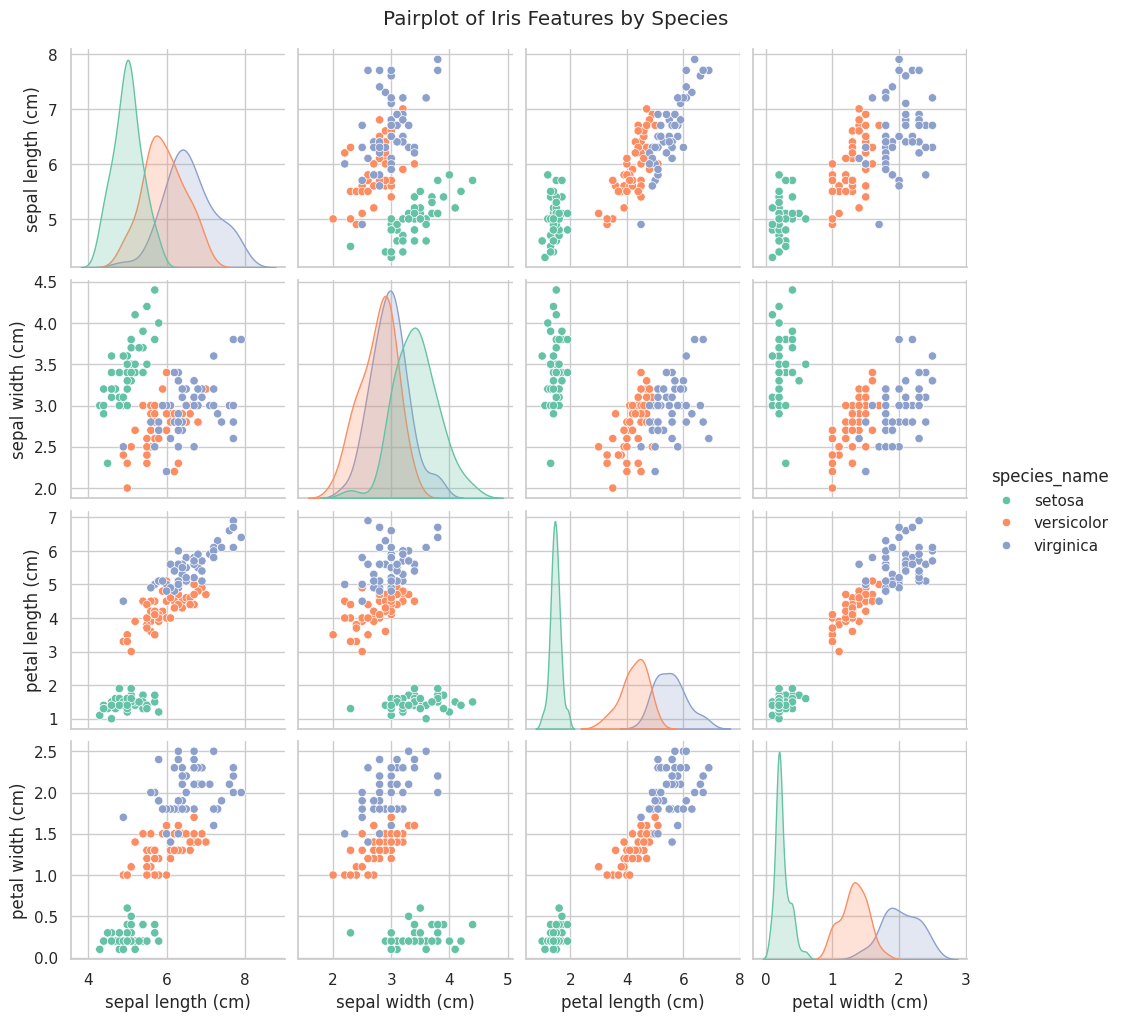

/tmp/ipykernel_4412/2542031666.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, ax=axes[i], palette='Set2')
/tmp/ipykernel_4412/2542031666.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, ax=axes[i], palette='Set2')
/tmp/ipykernel_4412/2542031666.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, ax=axes[i], palette='Set2')
/tmp/ipykernel_4412/2542031666.py:57: FutureWarning: 

Passing `palette` without assigning `hue` 

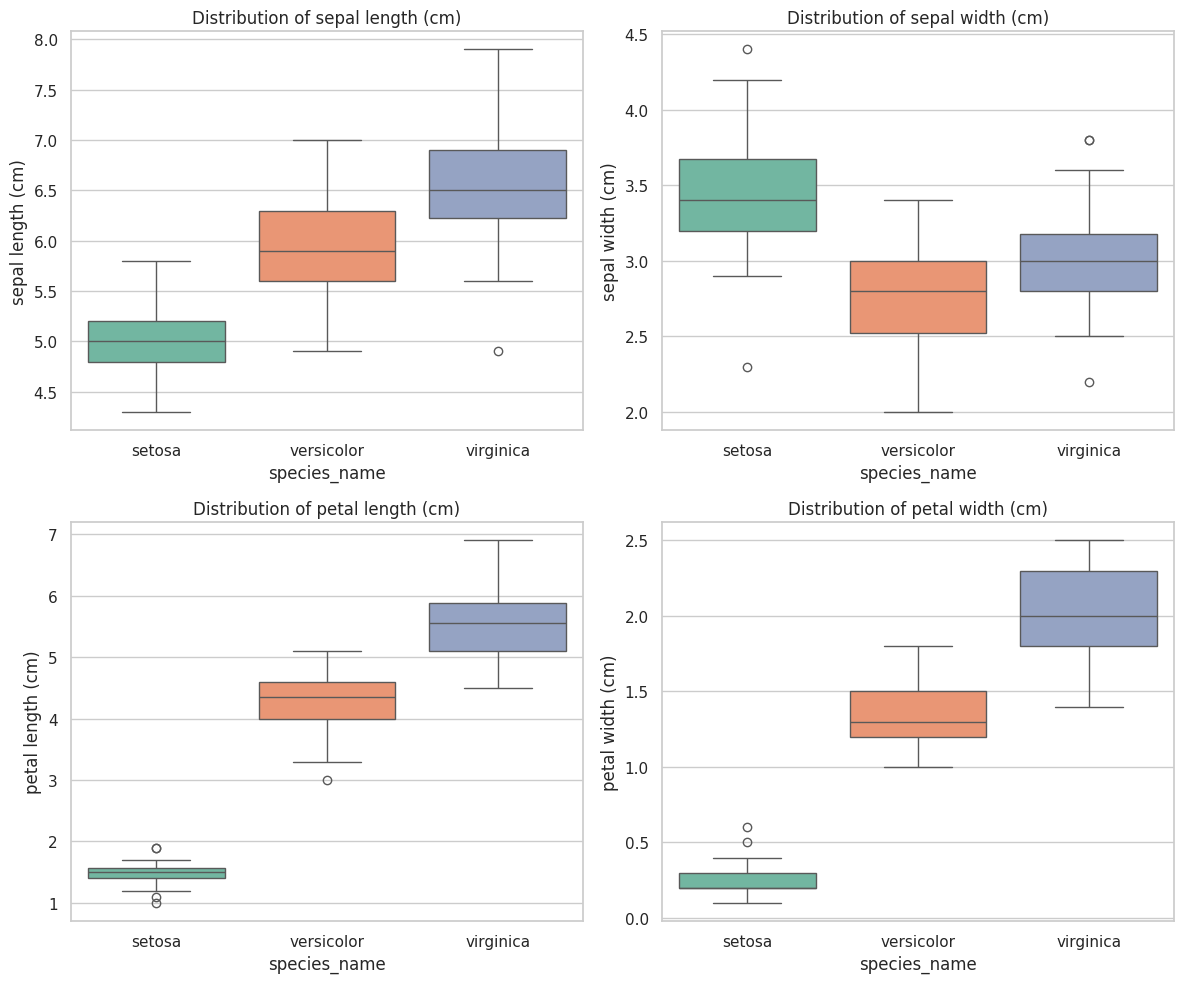

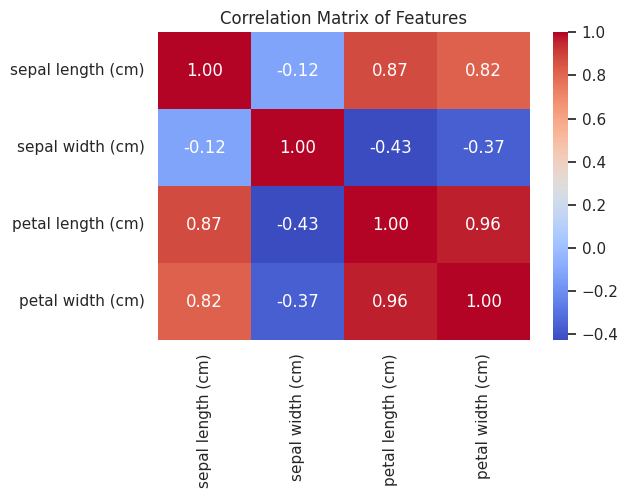

Training set size: 120 samples
Testing set size: 30 samples

=== Evaluating Logistic Regression ===
Accuracy Score: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



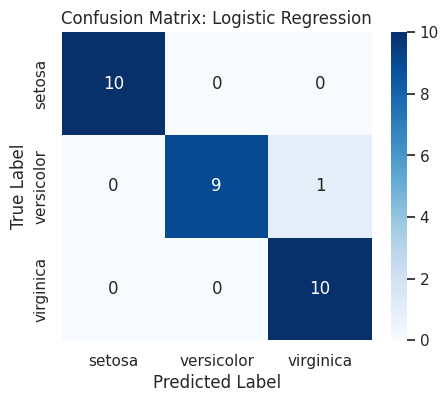

--------------------------------------------------
=== Evaluating Random Forest ===
Accuracy Score: 0.9000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



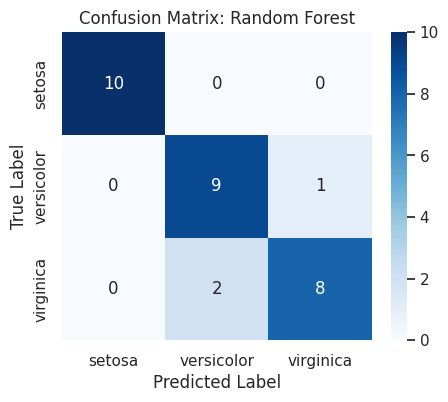

--------------------------------------------------
=== Final Conclusion ===
Logistic Regression: 96.67% Accuracy
Random Forest: 90.00% Accuracy

Conclusion: The **Logistic Regression** performed best (or tied) on the test data.
Justification: Given the small, clean, and highly distinct boundaries of the Iris dataset, both models traditionally achieve near 100% accuracy. Random Forest handles non-linear boundaries exceptionally well, whereas Logistic Regression works flawlessly here due to linear separation paths.


In [9]:

# TASK 1: Iris Flower Classification


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


sns.set_theme(style="whitegrid")


iris = load_iris(as_frame=True)


df = iris.frame

df['species_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("--- Dataset Loaded Successfully ---")
print(f"Features: {iris.feature_names}\n")


print("--- [EDA] Shape of the Dataset ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- [EDA] Data Types ---")
print(df.dtypes, "\n")

print("--- [EDA] Null Value Check ---")
print(df.isnull().sum(), "\n")

print("--- [EDA] Descriptive Statistics ---")
print(df.describe(), "\n")


# Feature names inside the dataframe for plotting
features = iris.feature_names


pair_plot = sns.pairplot(df, vars=features, hue='species_name', palette='Set2')
pair_plot.fig.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

# Box plots: Checking distribution and outliers for each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='species_name', y=feature, ax=axes[i], palette='Set2')
    axes[i].set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()


# Calculate correlation matrix using only numeric feature columns
corr_matrix = df[features].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

"""
FEATURE SELECTION DISCUSSION:
Looking at the pairplot and box plots:
- 'petal length (cm)' and 'petal width (cm)' are highly discriminative.
- 'setosa' is completely linearly separable from the other two species using just petal measurements.
- 'sepal width (cm)' has the most overlap among species, making it the least discriminative feature on its own.
"""


X = df[features]
y = df['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples\n")


models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"=== Evaluating {name} ===")
    # Train the model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"Accuracy Score: {acc:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print("-" * 50)


print("=== Final Conclusion ===")
for name, acc in results.items():
    print(f"{name}: {acc * 100:.2f}% Accuracy")

best_model = max(results, key=results.get)
print(f"\nConclusion: The **{best_model}** performed best (or tied) on the test data.")
print("Justification: Given the small, clean, and highly distinct boundaries of the Iris dataset, "
      "both models traditionally achieve near 100% accuracy. Random Forest handles non-linear boundaries "
      "exceptionally well, whereas Logistic Regression works flawlessly here due to linear separation paths.")
